<a href="https://colab.research.google.com/github/saraxfl/Notebook/blob/main/Collab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge # import ridge
from sklearn.ensemble import RandomForestRegressor


#Load the diabetes dataset

diabetes= load_diabetes()
x=diabetes.data
y=diabetes.target

#split the data into trainign and testing sets
x_train, x_test, y_train , y_test = train_test_split (x,y,test_size=0.2 ,random_state=42)


#create modele

models= {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge (),
    "Random Forest" : RandomForestRegressor(random_state=42)

}


#Train the models and compute MSE

for name, model in models.items():
  model.fit(x_train,y_train)
  y_pred= model.predict (x_test)
  mse= mean_squared_error (y_test,y_pred)
  print(f"{name} - Mean Squared Error: {mse:.2f}")

Linear Regression - Mean Squared Error: 2900.19
Ridge - Mean Squared Error: 3077.42
Random Forest - Mean Squared Error: 2952.01


Linear Regression: MAE = 52.26
Ridge: MAE = 55.96
Lasso: MAE = 54.28


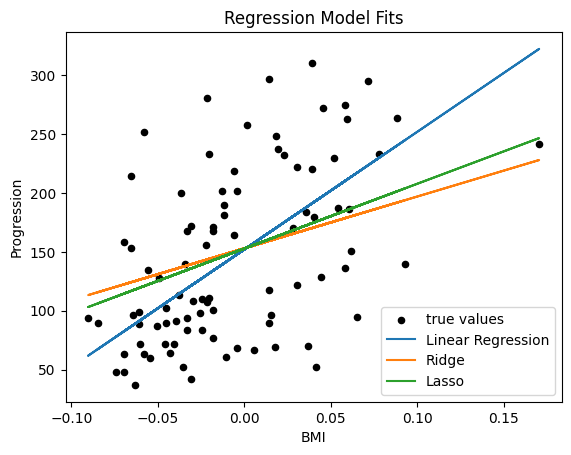

In [ ]:
# Import necessary libraries
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Import Lasso
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt  # Import matplotlib for plotting

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 2]  # Using only the 'bmi' feature, use 'diabetes' instead of 'data'
y = diabetes.target

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a dictionary of different regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
}

# Plot the true data points (using scatter function)
plt.scatter(X_test, y_test, color='black', s=20, marker='o', label='true values')  # Use 'scatter' to plot

# Plot model predictions
for name, model in models.items():
    model.fit(X_train, y_train)  # Train model
    predictions = model.predict(X_test)  # Make predictions
    plt.plot(X_test, predictions, label=name)  # Using plot function to plot predictions as lines
    # Print MAE for each model
    mae = mean_absolute_error(y_test, predictions)
    print(f"{name}: MAE = {mae:.2f}")

plt.xlabel('BMI')
plt.ylabel('Progression')
plt.title('Regression Model Fits')
plt.legend()
plt.show()

LinearRegression RMSE: 53.12
DecisionTreeRegressor RMSE: 72.89
RandomForestRegressor RMSE: 53.19


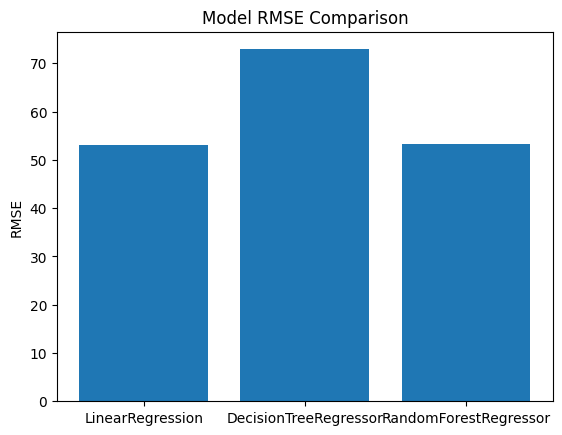

In [2]:
from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor()
}

rmse_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    rmse_scores.append((name, rmse))
    print(f"{name} RMSE: {rmse:.2f}")

names, scores = zip(*rmse_scores)

plt.bar(names, scores)
plt.ylabel("RMSE")
plt.title("Model RMSE Comparison")
plt.show()

LinearRegression R^2 Score: 0.48
DecisionTreeRegressor R^2 Score: -0.03
RandomForestRegressor R^2 Score: 0.46


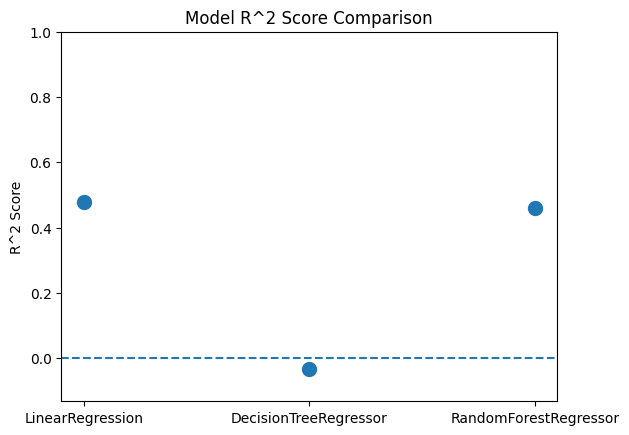

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor()
}

r2_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    r2 = model.score(X_test, y_test)
    r2_scores.append((name, r2))
    print(f"{name} R^2 Score: {r2:.2f}")

names, scores = zip(*r2_scores)

plt.scatter(names, scores, s=100)
plt.axhline(0, linestyle="--")
plt.ylabel("R^2 Score")
plt.title("Model R^2 Score Comparison")
plt.ylim(min(scores) - 0.1, 1)
plt.show()

LinearRegression MAPE: 36.67%
Ridge MAPE: 41.31%
Lasso MAPE: 45.34%
DecisionTreeRegressor MAPE: 54.49%
RandomForestRegressor MAPE: 38.53%
SVR MAPE: 48.63%


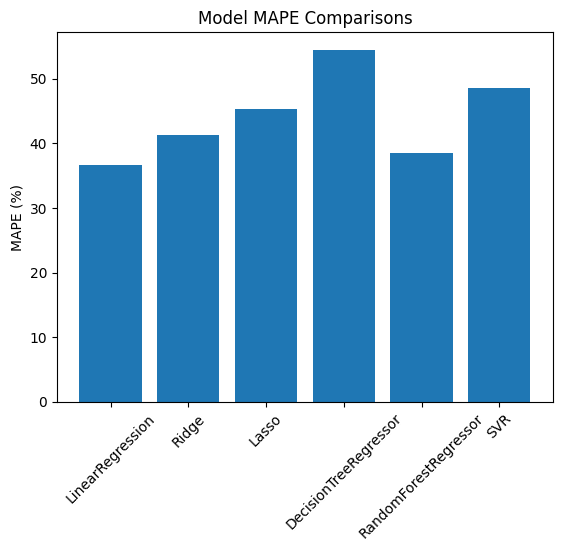

In [4]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    return np.mean(
        np.abs(
            (y_true[non_zero_indices] - y_pred[non_zero_indices])
            / y_true[non_zero_indices]
        )
    ) * 100

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "SVR": SVR()
}

mape_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, predictions)
    mape_scores.append((name, mape))
    print(f"{name} MAPE: {mape:.2f}%")

names, scores = zip(*mape_scores)

plt.bar(names, scores)
plt.ylabel("MAPE (%)")
plt.title("Model MAPE Comparisons")
plt.xticks(rotation=45)
plt.show()

LinearRegression RMSLE: 0.4124
Ridge RMSLE: 0.4250
Lasso RMSLE: 0.4496
DecisionTreeRegressor RMSLE: 0.5695
RandomForestRegressor RMSLE: 0.4127
SVR RMSLE: 0.4864


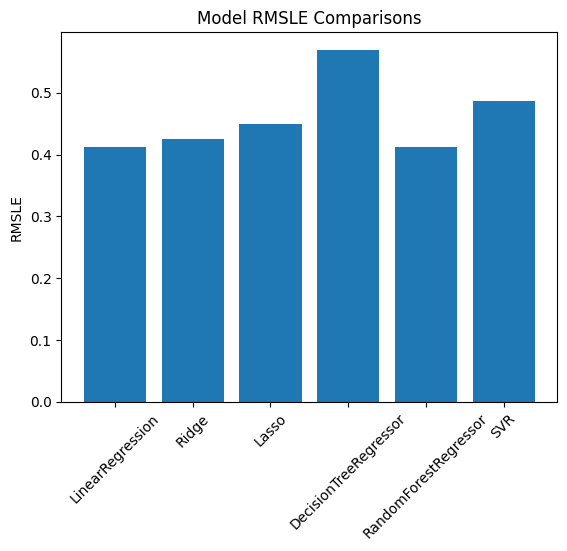

In [5]:
from sklearn.metrics import mean_squared_log_error
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

def root_mean_squared_log_error(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-10, np.inf)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

models = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge()),
    ("Lasso", Lasso()),
    ("DecisionTreeRegressor", DecisionTreeRegressor()),
    ("RandomForestRegressor", RandomForestRegressor()),
    ("SVR", SVR())
]

rmsle_scores = []

for name, model in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmsle = root_mean_squared_log_error(y_test, predictions)
    rmsle_scores.append((name, rmsle))
    print(f"{name} RMSLE: {rmsle:.4f}")

names, scores = zip(*rmsle_scores)

plt.bar(names, scores)
plt.ylabel("RMSLE")
plt.title("Model RMSLE Comparisons")
plt.xticks(rotation=45)
plt.show()